# 🚀 Introduction

This notebook focuses on building a stock price prediction model using Support Vector Regression (SVR). The model is trained on 15 years of historical closing prices for AAPL stock, using a feature set that includes 60-day lag values and moving averages (7-day and 30-day). These features help capture short-term and medium-term trends in price movement.

Once the model is trained on AAPL data, it is tested on a selection of other major tech stocks, including GOOG, MSFT, META, AMZN, and others. For each stock, the model attempts to predict the closing price based on the same engineered features. The notebook generates individual line charts showing actual vs. predicted prices for each stock, and prints the RMSE value on top of each plot to help assess prediction accuracy.


### Importing Dependencies

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error



### Importing AAPL stock prices

In [13]:
# Step 1: Import AAPL Stock Data
# Define the start and end dates manually
start_date = '2010-01-01'  # Example start date
end_date = '2025-01-01'    # Example end date
ticker = 'AAPL'
data = yf.download(ticker, start=start_date, end=end_date, interval='1d')[['Close']]
data.dropna(inplace=True)

# Step 2: Convert Close Prices to a Numpy Array
df = data.copy()
df['Close'] = df['Close'].astype(float)  # Ensure proper type



[*********************100%***********************]  1 of 1 completed


### Creating features for input (lag days and moving averages)

In [14]:
# Step 3: Create Features (Lag Days and Moving Averages)
num_lags = 60  # Number of lag days
for lag in range(1, num_lags + 1):
    df[f'lag_{lag}'] = df['Close'].shift(lag)

df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

df.dropna(inplace=True)  # Drop NaN values created by shifting

print(df)

Price            Close       lag_1       lag_2       lag_3       lag_4  \
Ticker            AAPL                                                   
Date                                                                     
2010-03-31    7.071995    7.097574    6.993450    6.948612    6.820713   
2010-04-01    7.101187    7.071995    7.097574    6.993450    6.948612   
2010-04-05    7.177022    7.101187    7.071995    7.097574    6.993450   
2010-04-06    7.208622    7.177022    7.101187    7.071995    7.097574   
2010-04-07    7.240520    7.208622    7.177022    7.101187    7.071995   
...                ...         ...         ...         ...         ...   
2024-12-24  257.916443  254.989655  254.210510  249.515656  247.777573   
2024-12-26  258.735504  257.916443  254.989655  254.210510  249.515656   
2024-12-27  255.309296  258.735504  257.916443  254.989655  254.210510   
2024-12-30  251.923019  255.309296  258.735504  257.916443  254.989655   
2024-12-31  250.144974  251.923019  25

In [15]:
# Step 4: Prepare Feature Matrix X and Target Variable y
X = df.drop(columns=['Close']).values
y = df['Close'].values



In [16]:
print(X,y)

(array([[  7.09757376,   6.99344969,   6.94861221, ...,   6.44033051,
           6.95815543,   6.56823867],
        [  7.07199478,   7.09757376,   6.99344969, ...,   6.45146561,
           6.99087157,   6.60138183],
        [  7.10118675,   7.07199478,   7.09757376, ...,   6.34884644,
           7.03007896,   6.63831673],
        ...,
        [258.73550415, 257.91644287, 254.98965454, ..., 226.28196716,
         254.06494795, 242.07584127],
        [255.30929565, 258.73550415, 257.91644287, ..., 225.17440796,
         254.65715463, 242.87429657],
        [251.92301941, 255.30929565, 258.73550415, ..., 226.30194092,
         254.74705723, 243.72069956]]),
 array([[  7.07199478],
        [  7.10118675],
        [  7.17702246],
        ...,
        [255.30929565],
        [251.92301941],
        [250.14497375]]))

### Standardization of input data points

In [17]:
# Step 5: Standardize Features (SVR is sensitive to feature scaling)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 6: Train Support Vector Regression (SVR) Model
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X, y)



C:\Users\danis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR(C=100)

### Fitting data to SVR model

In [18]:
# Step 7: Make Predictions
y_pred = svr_model.predict(X)

# Step 8: Calculate RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f'RMSE: {rmse:.2f}')



RMSE: 1.58


### Plot showing actual and predicted stock prices for AAPL stock

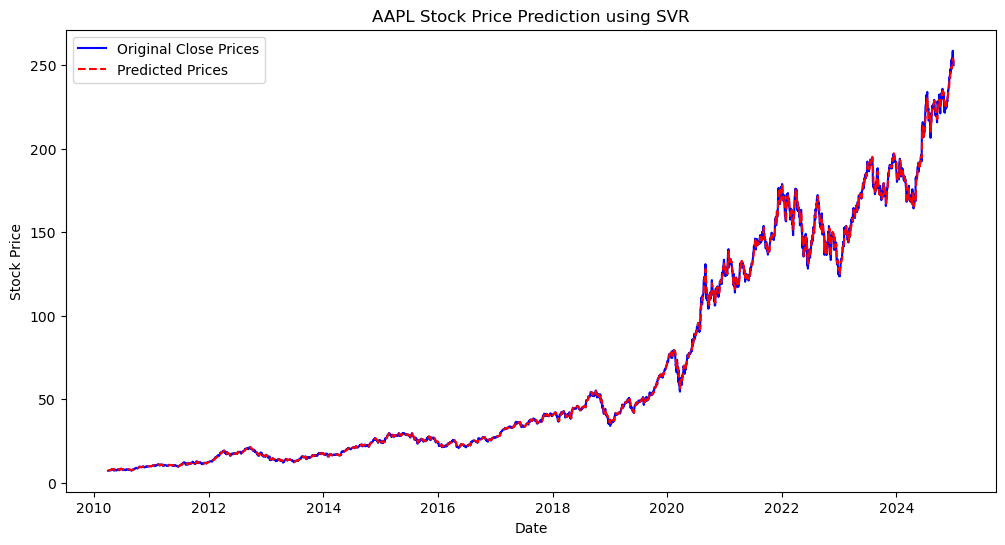

In [19]:
# Step 9: Plot Original and Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Original Close Prices', color='blue')
plt.plot(df.index, y_pred, label='Predicted Prices', color='red', linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title(f'{ticker} Stock Price Prediction using SVR')
plt.legend()
plt.show()


### Generating similar plots for the following stocks along with their RMSE values -
### 'GOOG', 'MSFT', 'META', 'AMZN', 'NVDA', 'QCOM', 'TSLA', 'NFLX', 'AMD', 'IBM'

[*********************100%***********************]  1 of 1 completed


Processing GOOG...


GOOG RMSE: 1.45


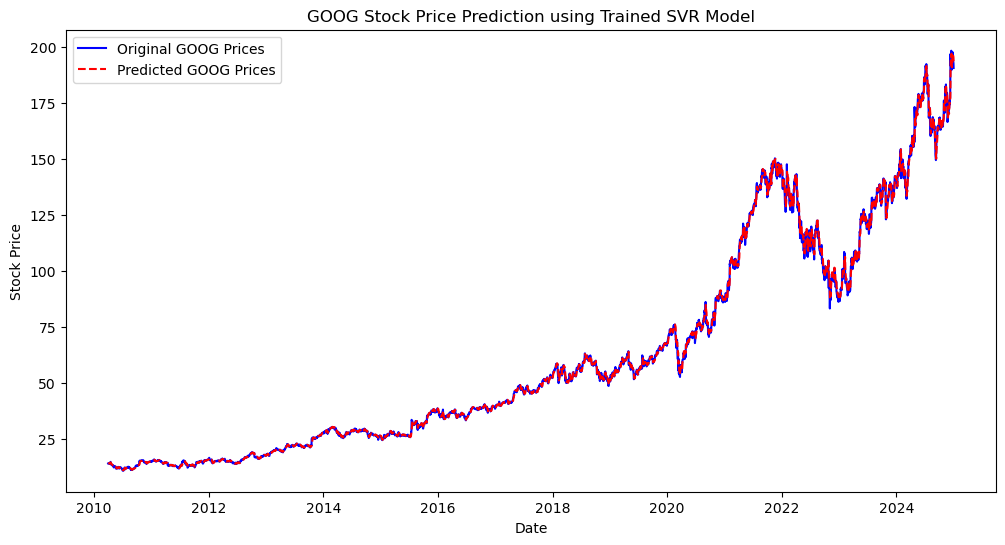


Processing MSFT...


[*********************100%***********************]  1 of 1 completed


MSFT RMSE: 89.34


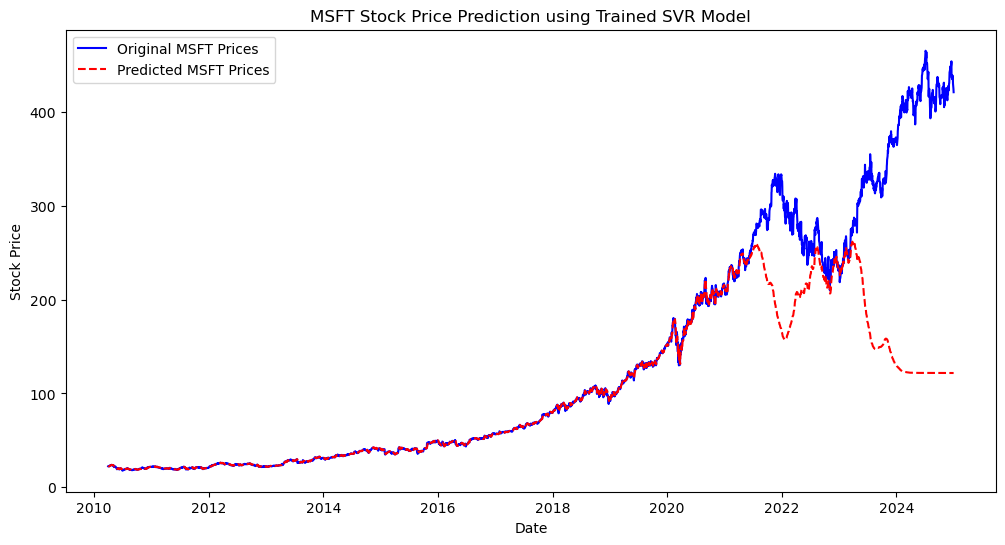


Processing META...


[*********************100%***********************]  1 of 1 completed


META RMSE: 123.58


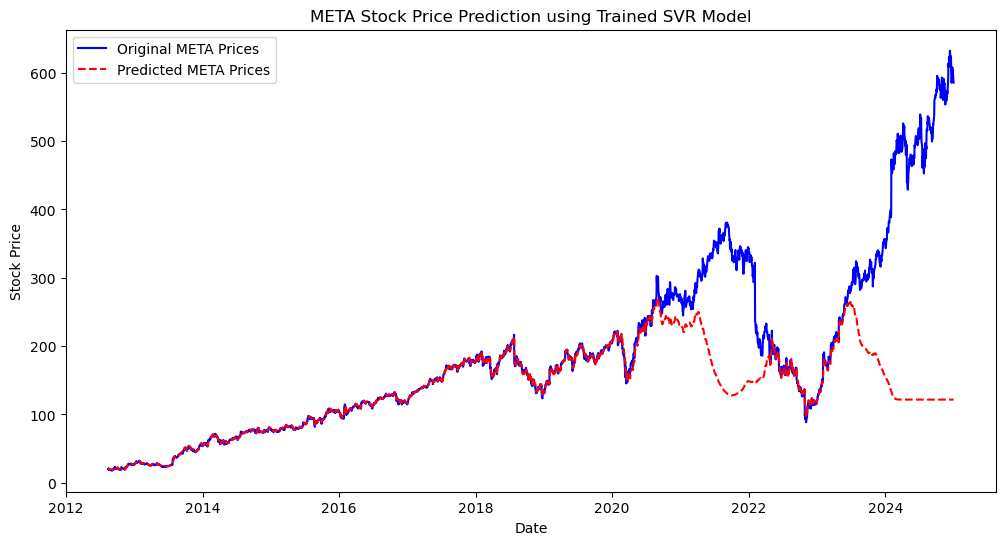


Processing AMZN...


[*********************100%***********************]  1 of 1 completed


AMZN RMSE: 2.05


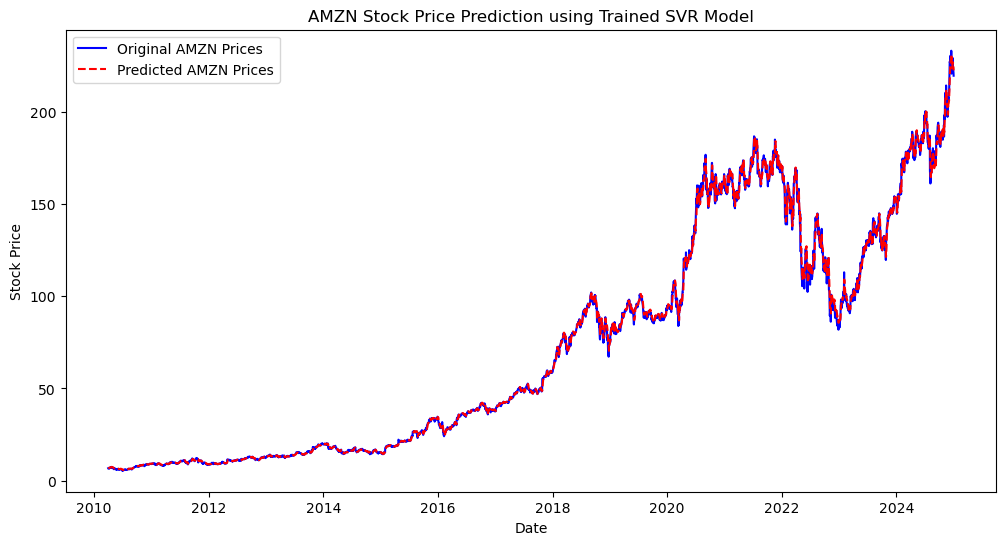


Processing NVDA...


[*********************100%***********************]  1 of 1 completed


NVDA RMSE: 1.18


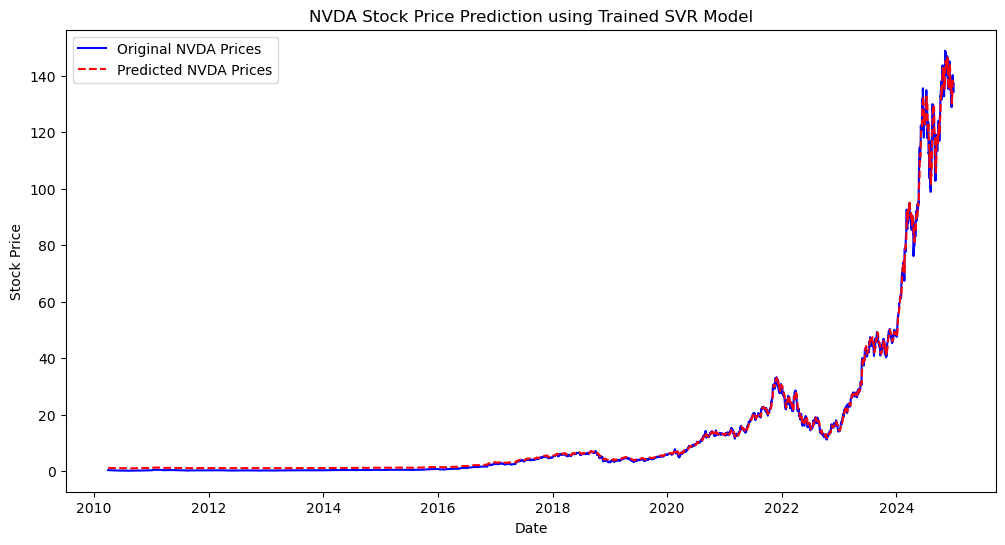


Processing QCOM...


[*********************100%***********************]  1 of 1 completed


QCOM RMSE: 2.10


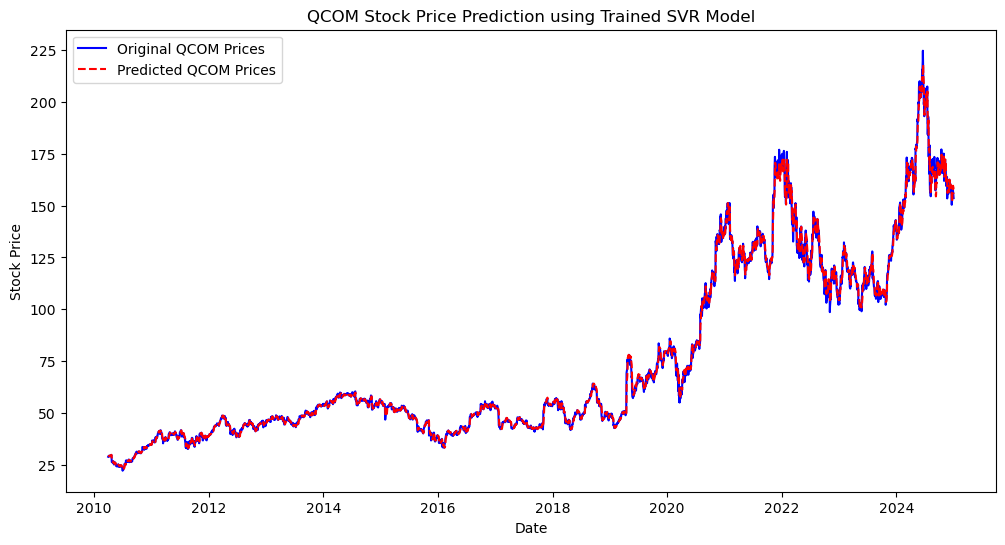


Processing TSLA...


[*********************100%***********************]  1 of 1 completed


TSLA RMSE: 41.08


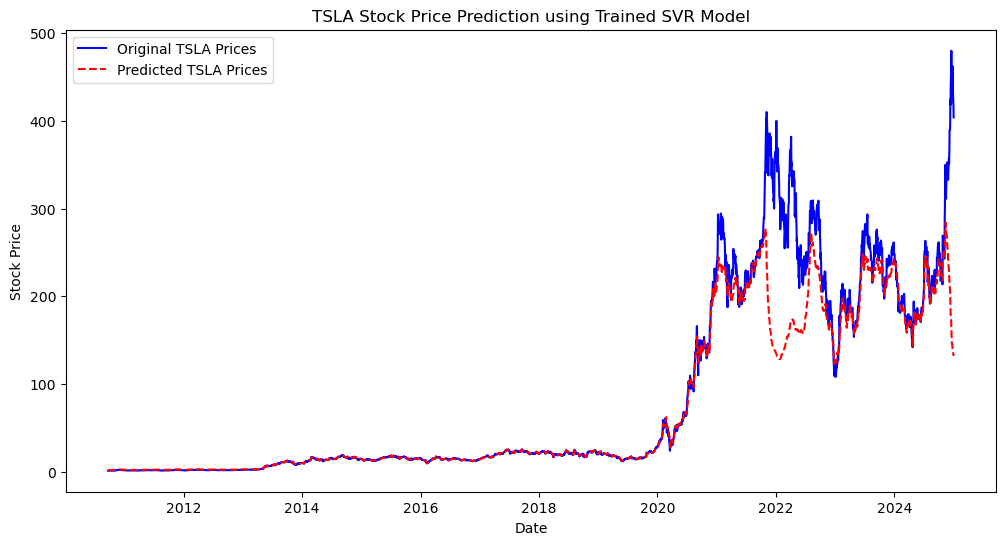


Processing NFLX...


[*********************100%***********************]  1 of 1 completed


NFLX RMSE: 228.62


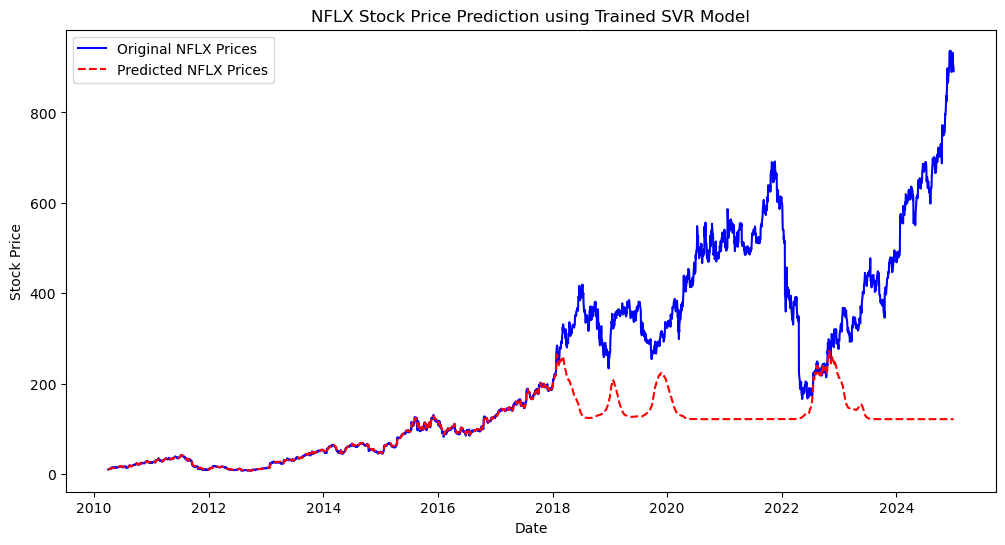


Processing AMD...


[*********************100%***********************]  1 of 1 completed


AMD RMSE: 2.20


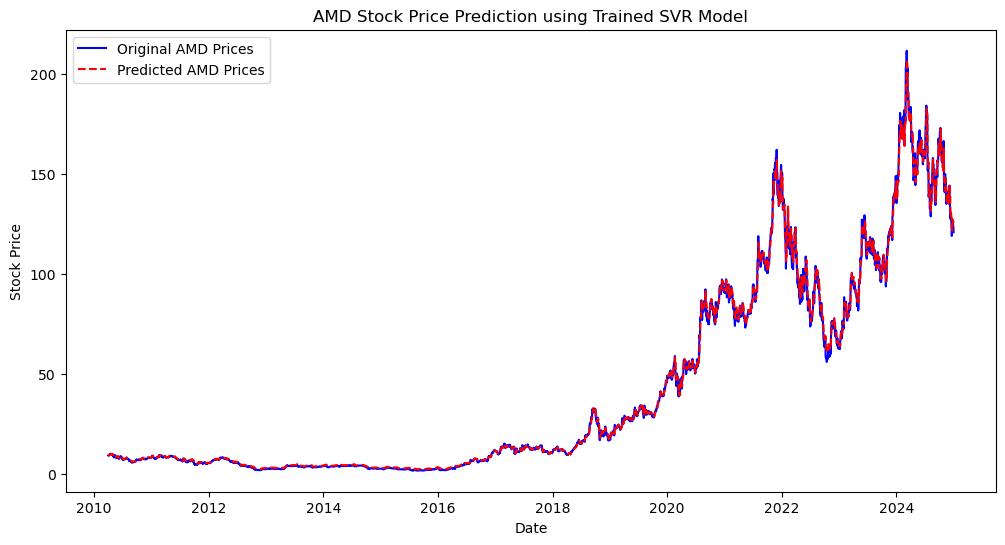


Processing IBM...


[*********************100%***********************]  1 of 1 completed


IBM RMSE: 1.71


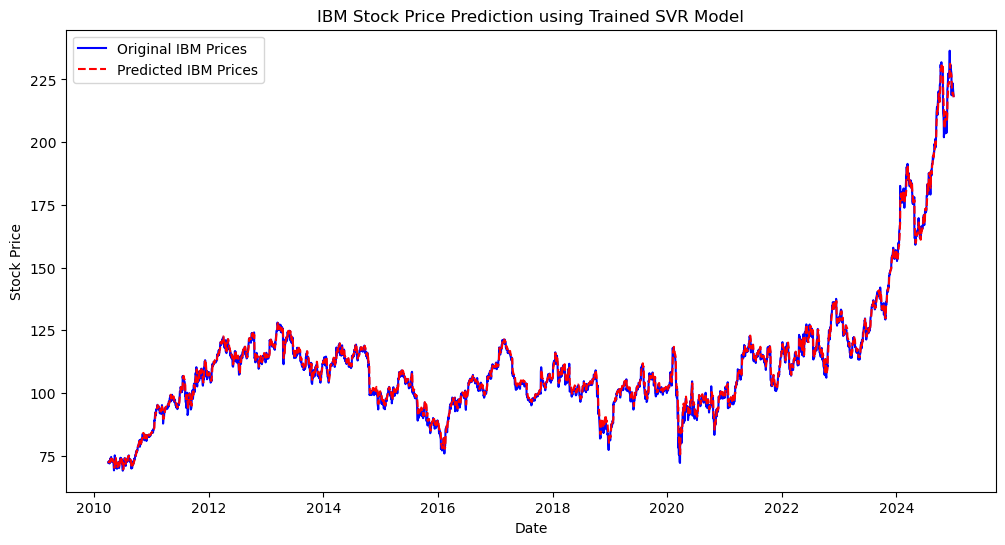

In [21]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# List of top 10 stocks
tickers = ['GOOG', 'MSFT', 'META', 'AMZN', 'NVDA', 'QCOM', 'TSLA', 'NFLX', 'AMD', 'IBM']

start_date = '2010-01-01'
end_date = '2025-01-01'
num_lags = 60  # Same lag features as used in training

# Loop over each stock
for ticker in tickers:
    print(f"\nProcessing {ticker}...")

    # Download stock data
    data_stock = yf.download(ticker, start=start_date, end=end_date)[['Close']]
    data_stock.dropna(inplace=True)

    # Create Features
    df_stock = data_stock.copy()
    for lag in range(1, num_lags + 1):
        df_stock[f'lag_{lag}'] = df_stock['Close'].shift(lag)

    df_stock['MA_7'] = df_stock['Close'].rolling(window=7).mean()
    df_stock['MA_30'] = df_stock['Close'].rolling(window=30).mean()

    df_stock.dropna(inplace=True)

    # Prepare Feature Matrix
    X_stock = df_stock.drop(columns=['Close']).values
    X_stock = scaler.transform(X_stock)  # Use the same scaler from training

    # Make Predictions
    y_pred_stock = svr_model.predict(X_stock)

    # Compute RMSE
    rmse = np.sqrt(mean_squared_error(df_stock['Close'], y_pred_stock))
    print(f'{ticker} RMSE: {rmse:.2f}')

    # Plot Actual vs Predicted
    plt.figure(figsize=(12, 6))
    plt.plot(df_stock.index, df_stock['Close'], label=f'Original {ticker} Prices', color='blue')
    plt.plot(df_stock.index, y_pred_stock, label=f'Predicted {ticker} Prices', color='red', linestyle='dashed')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.title(f'{ticker} Stock Price Prediction using Trained SVR Model')
    plt.legend()
    plt.show()


### 📈 Conclusion

This notebook showcased the use of Support Vector Regression (SVR) for forecasting stock prices using engineered features such as lagged closing prices and moving averages. The model was trained exclusively on 15 years of AAPL stock data and then tested on a set of prominent tech stocks to evaluate its generalization ability.

A key finding from this study is that the SVR model, despite being trained on a single stock, was able to deliver highly accurate predictions for multiple other tech stocks. In particular, the predictions for GOOG, AMZN, NVDA, QCOM, AMD, and IBM resulted in very low RMSE values, closely aligning with the actual stock prices. This observation suggests that many tech stocks may share underlying structural patterns and temporal behavior, enabling the model to generalize effectively across them.

These results reinforce the value of thoughtful feature engineering and highlight SVR’s potential in financial forecasting tasks, especially within sectors where stock behaviors are correlated or trend similarly.

---

### 🔍 Key Observations:
- ✅ The SVR model was trained only on AAPL stock data.
- ✅ It was tested on 9 other major tech stocks.
- 📉 Achieved **very low RMSE values** for:
  - GOOG
  - AMZN
  - NVDA
  - QCOM
  - AMD
  - IBM
- 💡 Indicates that **tech stocks may exhibit similar behavior**, making it possible to generalize predictions across them.
- 📊 Highlights SVR’s potential in capturing consistent patterns in time series data with properly engineered features.
